# EDA: Аналіз датасету виявлення прилітної дошки (Ramp Detection)

Розвідувальний аналіз для задачі детекції прилітної дошки вулика.

**Датасет:** YOLO Pose формат — кожне зображення містить одну анотацію рампи з bounding box та чотирма кутовими ключовими точками.

**Формат анотацій:** `class cx cy w h kp1x kp1y vis1 kp2x kp2y vis2 kp3x kp3y vis3 kp4x kp4y vis4` (нормалізовані координати 0–1)

**Структура аналізу:**
1. Завантаження даних
2. Загальна статистика
3. Аналіз джерел зображень
4. Аналіз bounding box (розмір, позиція, пропорції рампи)
5. Просторовий аналіз
6. Аналіз ключових точок
7. Приклади з анотаціями

In [2]:
import pandas as pd
import numpy as np
import os
import re
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

## 1. Завантаження даних

In [3]:
LABEL_DIR = "../datasets/raw/ramp/labels"
IMAGE_DIR = "../datasets/raw/ramp/images"

def load_ramp_data(label_dir):
    """Завантажує анотації рампи з .txt файлів у DataFrame.
    
    Формат: class cx cy w h kp1x kp1y vis1 kp2x kp2y vis2 kp3x kp3y vis3 kp4x kp4y vis4
    """
    records = []
    for fname in sorted(os.listdir(label_dir)):
        if not fname.endswith('.txt'):
            continue
        with open(os.path.join(label_dir, fname)) as f:
            line = f.readline().strip()
            if not line:
                continue
            vals = list(map(float, line.split()))
            records.append([fname] + vals)

    cols = ['file', 'class',
            'cx', 'cy', 'w', 'h',
            'kp1x', 'kp1y', 'vis1',
            'kp2x', 'kp2y', 'vis2',
            'kp3x', 'kp3y', 'vis3',
            'kp4x', 'kp4y', 'vis4']
    df = pd.DataFrame(records, columns=cols)

    # Похідні ознаки
    df['aspect_ratio'] = df['w'] / df['h']
    df['area'] = df['w'] * df['h']

    # Джерело зображення
    def extract_source(fname):
        if re.match(r'\d{8}[a-z]', fname):
            return re.match(r'(\d{8}[a-z])', fname).group(1)
        if fname.startswith('bee_'):
            return 'bee_external'
        if fname.startswith('vs_'):
            return 'vs_external'
        return 'other'

    df['source'] = df['file'].apply(extract_source)
    return df

df = load_ramp_data(LABEL_DIR)
print(f"Завантажено: {len(df)} зображень")
df.head()

Завантажено: 156 зображень


,file,class,cx,cy,w,h,kp1x,kp1y,vis1,kp2x,...,vis2,kp3x,kp3y,vis3,kp4x,kp4y,vis4,aspect_ratio,area,source
0,20230609a126_jpg.rf.33fa669d83bf5cefd693759f2d...,0.0,0.465278,0.535494,0.692708,0.271605,0.126736,0.410494,2.0,0.803819,...,2.0,0.791667,0.655864,2.0,0.133681,0.637346,2.0,2.550426,0.188143,20230609a
1,20230609a204_jpg.rf.a686b6686ce14c97d12b6d47df...,0.0,0.465278,0.535494,0.692708,0.271605,0.126736,0.410494,2.0,0.803819,...,2.0,0.791667,0.655864,2.0,0.133681,0.637346,2.0,2.550426,0.188143,20230609a
2,20230609a282_jpg.rf.f3c09450eaf21d0a66d736d26f...,0.0,0.465278,0.535494,0.692708,0.271605,0.126736,0.410494,2.0,0.803819,...,2.0,0.791667,0.655864,2.0,0.133681,0.637346,2.0,2.550426,0.188143,20230609a
3,20230609a48_jpg.rf.4309cdd31ce33a15d89bf2898e6...,0.0,0.465278,0.535494,0.692708,0.271605,0.126736,0.410494,2.0,0.803819,...,2.0,0.791667,0.655864,2.0,0.133681,0.637346,2.0,2.550426,0.188143,20230609a
4,20230609b264_jpg.rf.13253e6b8efc02d1bdfbad815d...,0.0,0.487847,0.575617,0.727431,0.262346,0.130208,0.450617,2.0,0.844618,...,2.0,0.842882,0.694444,2.0,0.134549,0.694444,2.0,2.772795,0.190838,20230609b


## 2. Загальна статистика

In [4]:
print("=== ЗАГАЛЬНА СТАТИСТИКА ДАТАСЕТУ ===")
print(f"Кількість зображень:        {len(df)}")
print(f"Унікальних джерел:          {df['source'].nunique()}")
print(f"\nBounding Box (нормалізовані):")
print(f"  ширина (w):    {df['w'].mean():.3f} ± {df['w'].std():.3f}  [{df['w'].min():.3f}–{df['w'].max():.3f}]")
print(f"  висота (h):    {df['h'].mean():.3f} ± {df['h'].std():.3f}  [{df['h'].min():.3f}–{df['h'].max():.3f}]")
print(f"  площа (w×h):   {df['area'].mean():.3f} ± {df['area'].std():.3f}")
print(f"  aspect ratio:  {df['aspect_ratio'].mean():.2f} ± {df['aspect_ratio'].std():.2f}")
print(f"\nВидимість ключових точок (2=видима, 1=закрита, 0=відсутня):")
for i in range(1, 5):
    vc = df[f'vis{i}'].value_counts().sort_index()
    print(f"  kp{i}: {dict(vc)}")

=== ЗАГАЛЬНА СТАТИСТИКА ДАТАСЕТУ ===
Кількість зображень:        156
Унікальних джерел:          10

Bounding Box (нормалізовані):
  ширина (w):    0.749 ± 0.108  [0.330–0.978]
  висота (h):    0.335 ± 0.068  [0.147–0.529]
  площа (w×h):   0.256 ± 0.079
  aspect ratio:  2.28 ± 0.32

Видимість ключових точок (2=видима, 1=закрита, 0=відсутня):
  kp1: {2.0: np.int64(156)}
  kp2: {2.0: np.int64(156)}
  kp3: {2.0: np.int64(156)}
  kp4: {2.0: np.int64(156)}


## 3. Аналіз джерел зображень

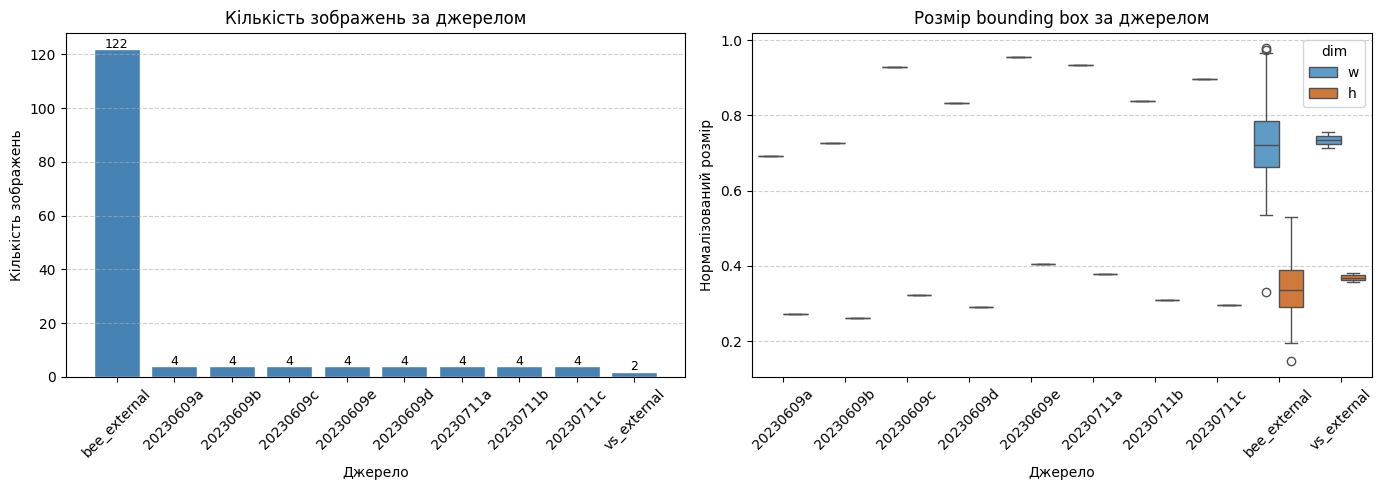

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Кількість зображень за джерелом
source_counts = df['source'].value_counts()
axes[0].bar(source_counts.index, source_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Кількість зображень за джерелом')
axes[0].set_xlabel('Джерело')
axes[0].set_ylabel('Кількість зображень')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(source_counts.values):
    axes[0].text(i, v + 0.5, str(v), ha='center', fontsize=9)

# Розмір рампи (w, h) за джерелом
df_melted = df.melt(id_vars='source', value_vars=['w', 'h'], var_name='dim', value_name='value')
sns.boxplot(data=df_melted, x='source', y='value', hue='dim', ax=axes[1], palette=['#4C9ED9', '#E87722'])
axes[1].set_title('Розмір bounding box за джерелом')
axes[1].set_xlabel('Джерело')
axes[1].set_ylabel('Нормалізований розмір')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Аналіз bounding box

Розподіл геометричних характеристик рампи: ширина, висота, площа, пропорції.

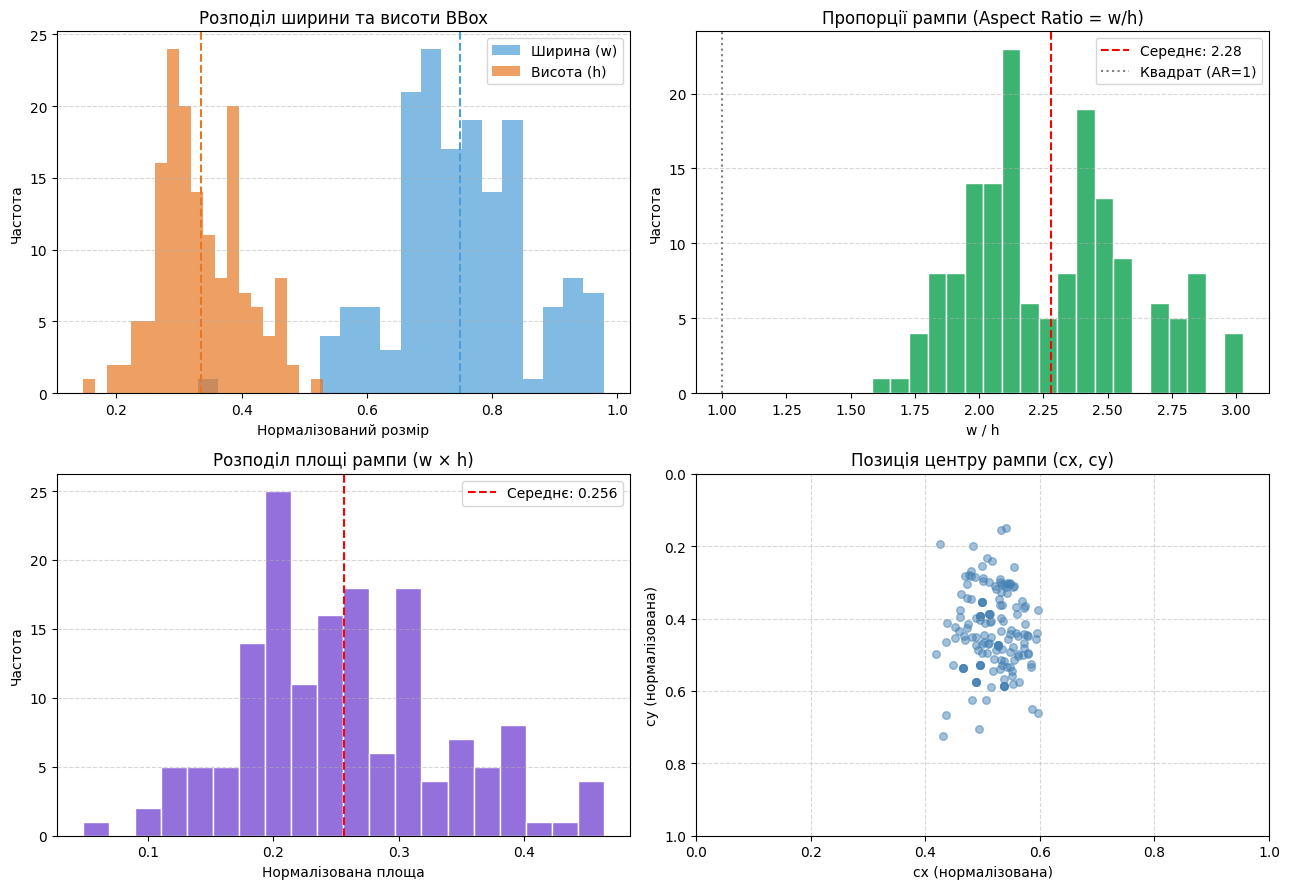

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# W та H разом
axes[0, 0].hist(df['w'], bins=20, alpha=0.7, color='#4C9ED9', label='Ширина (w)')
axes[0, 0].hist(df['h'], bins=20, alpha=0.7, color='#E87722', label='Висота (h)')
axes[0, 0].axvline(df['w'].mean(), color='#4C9ED9', linestyle='--', linewidth=1.5)
axes[0, 0].axvline(df['h'].mean(), color='#E87722', linestyle='--', linewidth=1.5)
axes[0, 0].set_title('Розподіл ширини та висоти BBox')
axes[0, 0].set_xlabel('Нормалізований розмір')
axes[0, 0].set_ylabel('Частота')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', linestyle='--', alpha=0.5)

# Aspect ratio
axes[0, 1].hist(df['aspect_ratio'], bins=20, color='mediumseagreen', edgecolor='white')
axes[0, 1].axvline(df['aspect_ratio'].mean(), color='red', linestyle='--',
                   label=f"Середнє: {df['aspect_ratio'].mean():.2f}")
axes[0, 1].axvline(1.0, color='gray', linestyle=':', label='Квадрат (AR=1)')
axes[0, 1].set_title('Пропорції рампи (Aspect Ratio = w/h)')
axes[0, 1].set_xlabel('w / h')
axes[0, 1].set_ylabel('Частота')
axes[0, 1].legend()
axes[0, 1].grid(axis='y', linestyle='--', alpha=0.5)

# Площа
axes[1, 0].hist(df['area'], bins=20, color='mediumpurple', edgecolor='white')
axes[1, 0].axvline(df['area'].mean(), color='red', linestyle='--',
                   label=f"Середнє: {df['area'].mean():.3f}")
axes[1, 0].set_title('Розподіл площі рампи (w × h)')
axes[1, 0].set_xlabel('Нормалізована площа')
axes[1, 0].set_ylabel('Частота')
axes[1, 0].legend()
axes[1, 0].grid(axis='y', linestyle='--', alpha=0.5)

# Scatter: позиція центру рампи
axes[1, 1].scatter(df['cx'], df['cy'], alpha=0.5, s=30, c='steelblue')
axes[1, 1].set_title('Позиція центру рампи (cx, cy)')
axes[1, 1].set_xlabel('cx (нормалізована)')
axes[1, 1].set_ylabel('cy (нормалізована)')
axes[1, 1].set_xlim(0, 1)
axes[1, 1].set_ylim(1, 0)
axes[1, 1].grid(linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 5. Просторовий аналіз

KDE-теплова карта центрів рамп у нормалізованому просторі зображення.

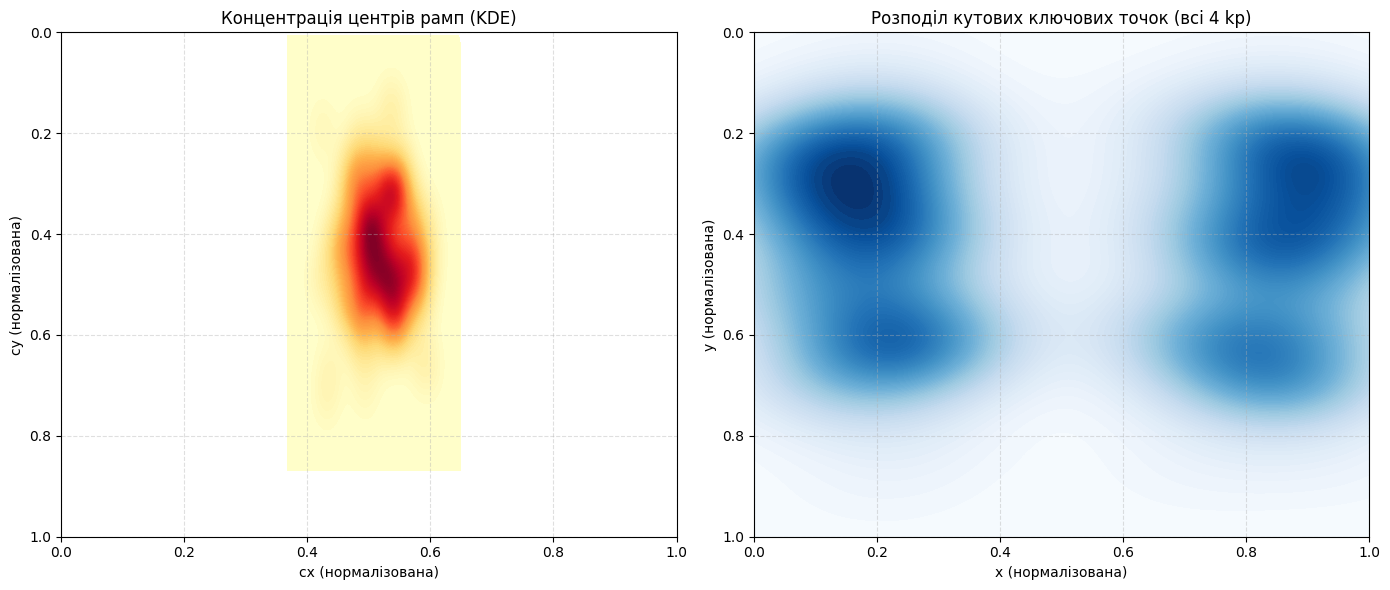

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# KDE центрів рамп
sns.kdeplot(x=df['cx'], y=df['cy'], fill=True, cmap='YlOrRd', thresh=0, levels=80, ax=axes[0])
axes[0].set_title('Концентрація центрів рамп (KDE)')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(1, 0)
axes[0].set_xlabel('cx (нормалізована)')
axes[0].set_ylabel('cy (нормалізована)')
axes[0].grid(linestyle='--', alpha=0.4)

# KDE всіх 4 кутових точок разом
all_kpx = pd.concat([df['kp1x'], df['kp2x'], df['kp3x'], df['kp4x']])
all_kpy = pd.concat([df['kp1y'], df['kp2y'], df['kp3y'], df['kp4y']])
sns.kdeplot(x=all_kpx, y=all_kpy, fill=True, cmap='Blues', thresh=0, levels=80, ax=axes[1])
axes[1].set_title('Розподіл кутових ключових точок (всі 4 kp)')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(1, 0)
axes[1].set_xlabel('x (нормалізована)')
axes[1].set_ylabel('y (нормалізована)')
axes[1].grid(linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## 6. Аналіз ключових точок

Середні позиції 4 кутів рампи (kp1–kp4) у нормалізованих координатах.

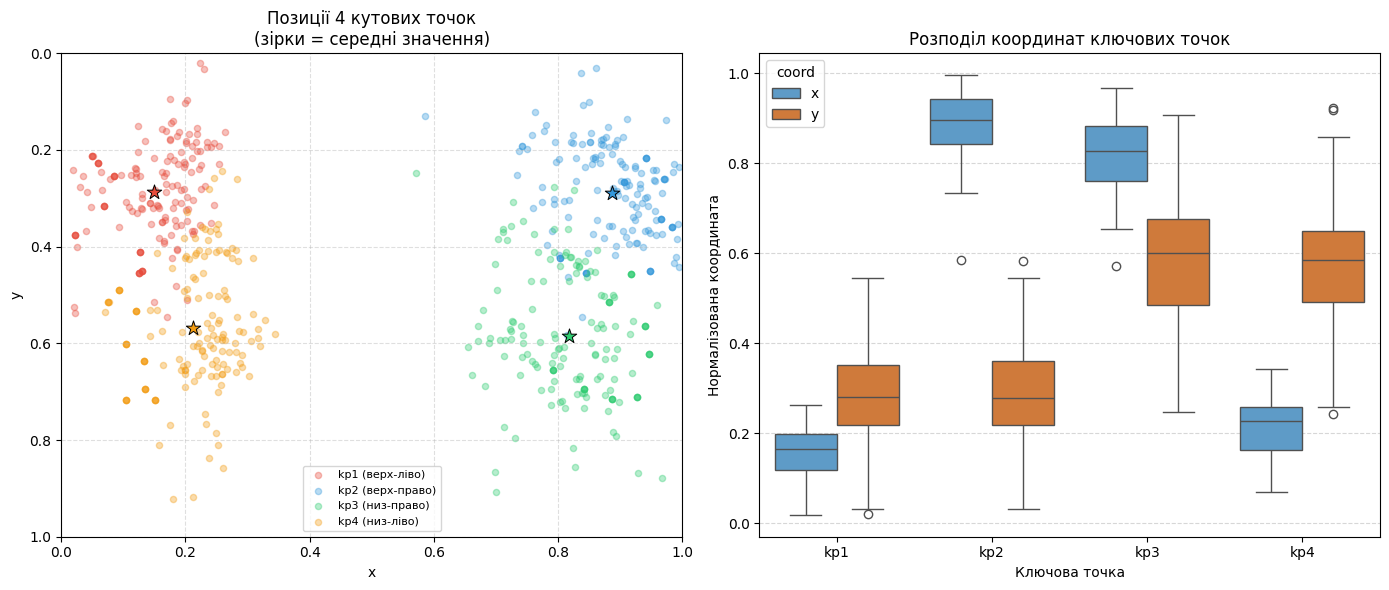

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter кожної точки окремим кольором
colors = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']
labels = ['kp1 (верх-ліво)', 'kp2 (верх-право)', 'kp3 (низ-право)', 'kp4 (низ-ліво)']

for i, (color, label) in enumerate(zip(colors, labels), start=1):
    axes[0].scatter(df[f'kp{i}x'], df[f'kp{i}y'], alpha=0.35, s=20, c=color, label=label)
    # Середня позиція
    axes[0].scatter(df[f'kp{i}x'].mean(), df[f'kp{i}y'].mean(),
                    s=120, c=color, marker='*', edgecolors='black', linewidths=0.7)

axes[0].set_title('Позиції 4 кутових точок\n(зірки = середні значення)')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(1, 0)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(fontsize=8)
axes[0].grid(linestyle='--', alpha=0.4)

# Боксплоти x та y координат для кожної точки
kp_data = []
for i in range(1, 5):
    for coord in ['x', 'y']:
        for val in df[f'kp{i}{coord}']:
            kp_data.append({'kp': f'kp{i}', 'coord': coord, 'value': val})
kp_df = pd.DataFrame(kp_data)

sns.boxplot(data=kp_df, x='kp', y='value', hue='coord', ax=axes[1], palette=['#4C9ED9', '#E87722'])
axes[1].set_title('Розподіл координат ключових точок')
axes[1].set_xlabel('Ключова точка')
axes[1].set_ylabel('Нормалізована координата')
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 7. Приклади з анотаціями

Випадкова вибірка зображень з нанесеними bounding box та ключовими точками (kp1–kp4).

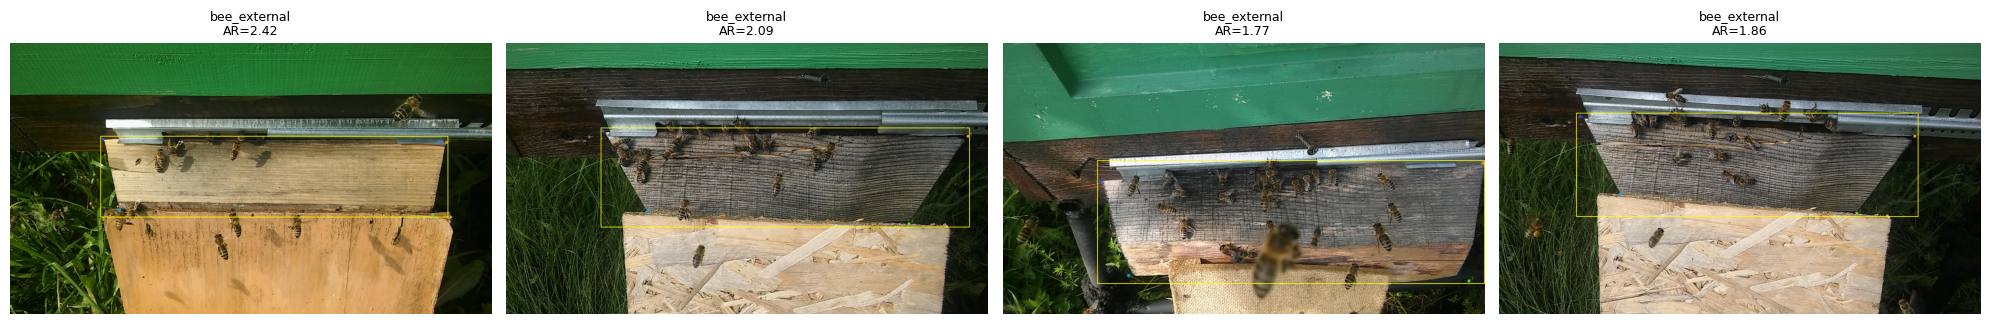

In [9]:
def visualize_ramp_samples(df, img_dir, n=4):
    sample = df.sample(n, random_state=42)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    kp_colors = [(231, 76, 60), (52, 152, 219), (46, 204, 113), (243, 156, 18)]  # BGR

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img_fname = row['file'].replace('.txt', '.jpg')
        img_path = os.path.join(img_dir, img_fname)
        img = cv2.imread(img_path)
        if img is None:
            ax.set_title('Зображення не знайдено')
            ax.axis('off')
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w_img = img.shape[:2]

        # Bounding box
        x1 = int((row['cx'] - row['w'] / 2) * w_img)
        y1 = int((row['cy'] - row['h'] / 2) * h)
        x2 = int((row['cx'] + row['w'] / 2) * w_img)
        y2 = int((row['cy'] + row['h'] / 2) * h)
        cv2.rectangle(img, (x1, y1), (x2, y2), (255, 255, 0), 2)

        # Ключові точки
        for i, color_rgb in enumerate(kp_colors, start=1):
            px = int(row[f'kp{i}x'] * w_img)
            py = int(row[f'kp{i}y'] * h)
            color_bgr = color_rgb[::-1]
            cv2.circle(img, (px, py), 6, color_bgr, -1)
            cv2.putText(img, str(i), (px + 7, py - 5),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.5, color_bgr, 1)

        ax.imshow(img)
        ax.set_title(f"{row['source']}\nAR={row['aspect_ratio']:.2f}", fontsize=9)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

visualize_ramp_samples(df, IMAGE_DIR)